In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import FunctionTransformer

# **Dataset 1: California Housing Dataset (Log Transformer)**

In [2]:
# Load dataset as a pandas DataFrame
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [19]:
df.sample(20)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Population_log,Population_Log
10908,3.3750,9.0,3.181818,1.036364,1257.0,7.618182,33.74,-117.86,1.65300,7.137278,7.137278
19096,4.8603,16.0,6.790155,1.077720,1247.0,3.230570,38.24,-122.60,1.98400,7.129298,7.129298
4984,3.0500,52.0,5.445378,1.033613,853.0,3.584034,34.00,-118.30,1.11600,6.749931,6.749931
17515,3.5750,44.0,5.138298,1.031915,676.0,2.397163,37.33,-121.93,2.92200,6.517671,6.517671
2534,2.8466,34.0,6.369565,1.062112,958.0,2.975155,39.60,-122.05,0.95300,6.865891,6.865891
11127,2.6563,29.0,3.651163,1.120930,1849.0,4.300000,33.84,-117.91,1.62500,7.522941,7.522941
3571,8.8612,24.0,7.901639,1.016393,1514.0,2.757741,34.25,-118.51,5.00001,7.323171,7.323171
14403,2.7857,36.0,4.894231,1.368590,710.0,2.275641,32.78,-117.25,2.91700,6.566672,6.566672
2145,2.1439,38.0,4.661765,0.997549,2142.0,2.625000,36.77,-119.76,0.60200,7.669962,7.669962
8883,7.8705,52.0,8.096774,1.118280,547.0,2.940860,34.03,-118.50,5.00001,6.306275,6.306275


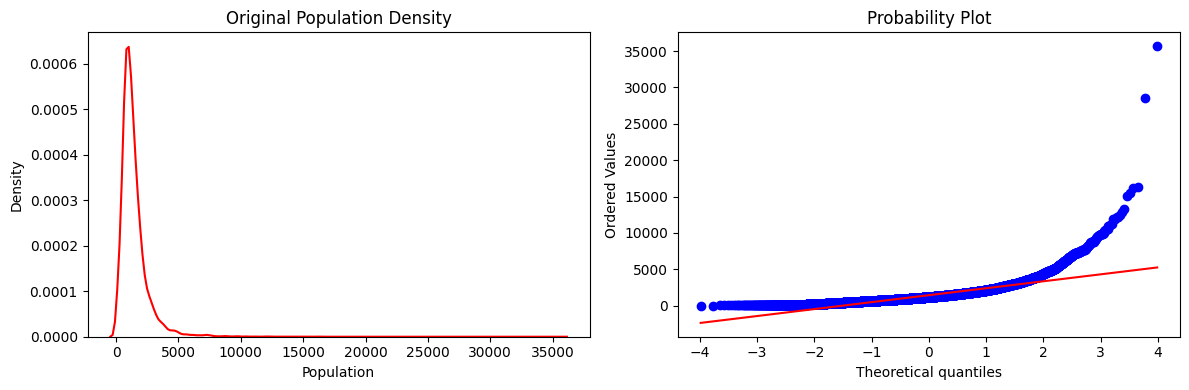

In [9]:
fig,ax = plt.subplots(1,2, figsize=(12,4))

# Left plot: Kernel Density Estimation (KDE) plot
ax[0].set_title('Original Population Density')
sns.kdeplot(df['Population'],ax=ax[0],color='red')

# Right plot: Quantile-Quantile (Q-Q) plot
ax[1].set_title('Original Population Q-Q Plot')
stats.probplot(df['Population'],dist='norm',plot=plt)

plt.tight_layout()
plt.show()


**Step 3: Thinking — Which transformer suits best?Observation: Most block groups have a few hundred to a couple thousand residents, but a few massive blocks have up to $35,000$+ residents.Skewness: Heavy Right-Skew (Positive Skew). The KDE plot stretches far to the right, and points on the Q-Q plot curve sharply away from the straight red line.Best Choice: Log Transformer (np.log1p). Logarithms squish huge values down significantly while keeping lower values readable.**

In [12]:
# 1.creating the transformer object
log_transformer = FunctionTransformer(func=np.log1p)

# 2.fit and transform the feature
# .fit_transform expects a 2D array so we pass df[['Population']]
population_log = log_transformer.fit_transform(df[['Population']])
df['Population_Log'] = population_log

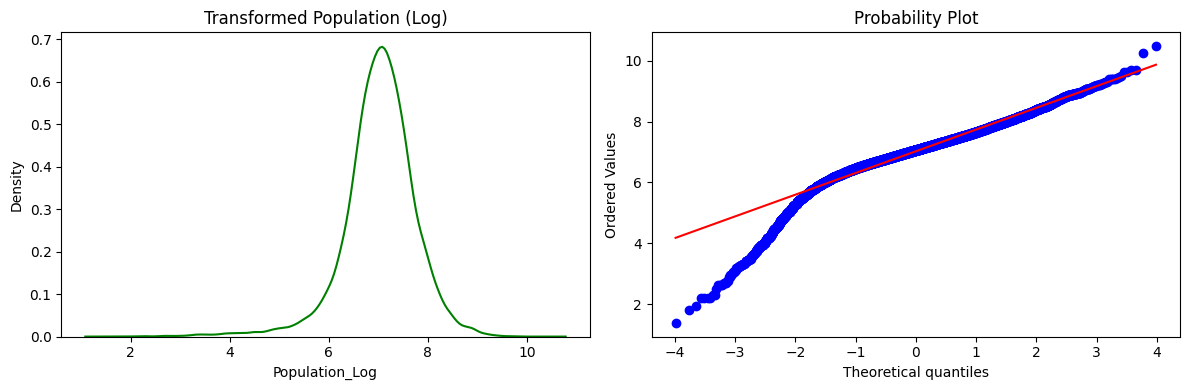

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].set_title('Transformed Population (Log)')
sns.kdeplot(df['Population_Log'], ax=ax[0], color='green')

ax[1].set_title('Transformed Population Q-Q Plot')
stats.probplot(df['Population_Log'], dist='norm', plot=plt)

plt.tight_layout()
plt.show()

# **Dataset 2: Synthetic Customer Experience Ratings (Square Transformer)**

Dataset 2: Synthetic Customer Experience Ratings (Square Transformer)
Most standard machine learning datasets consist of positive numbers or right-skewed data. Left-skewed data typically appears in satisfaction ratings or retirement age distributions. We can generate a small dataset representing Customer Satisfaction Scores (out of 100).

In [17]:
np.random.seed(42)

# Generate left-skewed scores: most customers rate ~80-100, very few rate low
scores = 100 - np.random.exponential(scale=10, size=500)
scores = np.clip(scores, 1, 100) # Keep between 1 and 100

df_customer = pd.DataFrame({'Satisfaction_Score': scores})
print(df_customer.sample(10))

     Satisfaction_Score
451           91.826396
174           89.638757
15            97.973886
393           85.020455
192           76.932256
40            98.698478
124           97.413133
317           98.096935
187           91.898676
140           67.179901


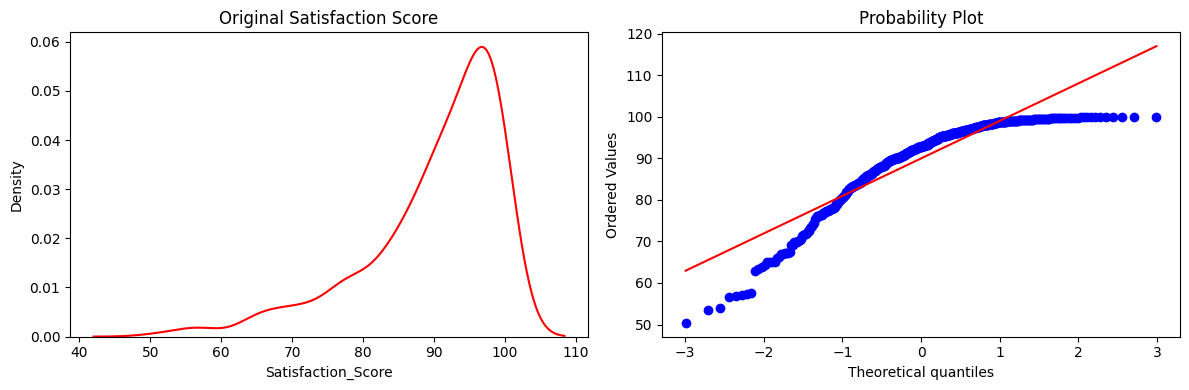

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].set_title('Original Satisfaction Score')
sns.kdeplot(df_customer['Satisfaction_Score'], ax=ax[0], color='red')

ax[1].set_title('Original Q-Q Plot')
stats.probplot(df_customer['Satisfaction_Score'], dist='norm', plot=plt)

plt.tight_layout()
plt.show()

**Which transformer suits best?Observation: High values (near 100) are clustered tightly together, while a long tail drags out toward lower values on the left.Skewness: Left-Skew (Negative Skew).Best Choice: Square Transformer ($x^2$). Squaring high numbers stretches them farther apart relative to small numbers (e.g., $90^2 = 8100$, while $30^2 = 900$), shifting the bulk of the distribution toward the center.**

In [22]:
# Create a square function using Python lambda
square_transformer = FunctionTransformer(func=lambda x:x**2)

#applying the transformation
df_customer['Satisfaction_Square'] = square_transformer.fit_transform(df_customer[['Satisfaction_Score']])

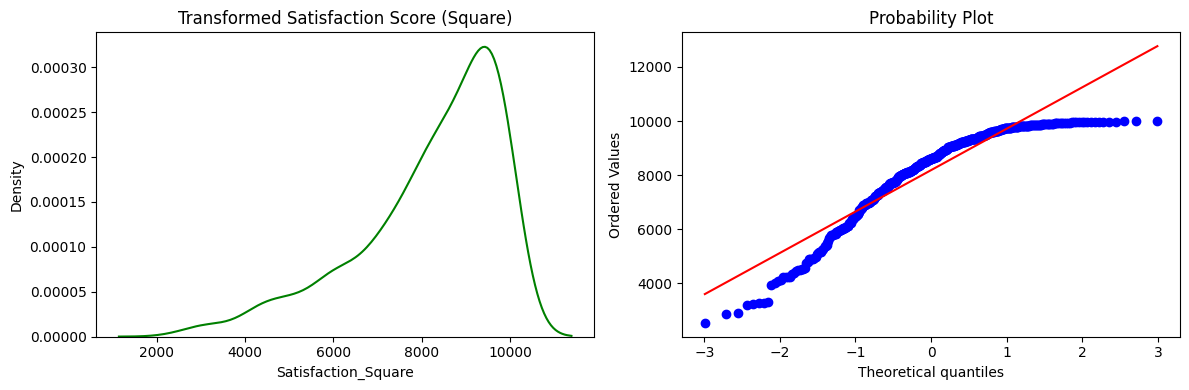

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].set_title('Transformed Satisfaction Score (Square)')
sns.kdeplot(df_customer['Satisfaction_Square'], ax=ax[0], color='green')

ax[1].set_title('Transformed Q-Q Plot')
stats.probplot(df_customer['Satisfaction_Square'], dist='norm', plot=plt)

plt.tight_layout()
plt.show()

# **Dataset 3: California Housing — Room Ratio (Reciprocal Transformer)**

Let's return to the California Housing dataset and calculate the average number of bedrooms per total room (AveBedrms / AveRooms).

In [26]:
# Compute bedroom ratio
df['Bedrooms_Per_Room'] = df['AveBedrms'] / df['AveRooms']

print(df[['Bedrooms_Per_Room']].head())

   Bedrooms_Per_Room
0           0.146591
1           0.155797
2           0.129516
3           0.184458
4           0.172096


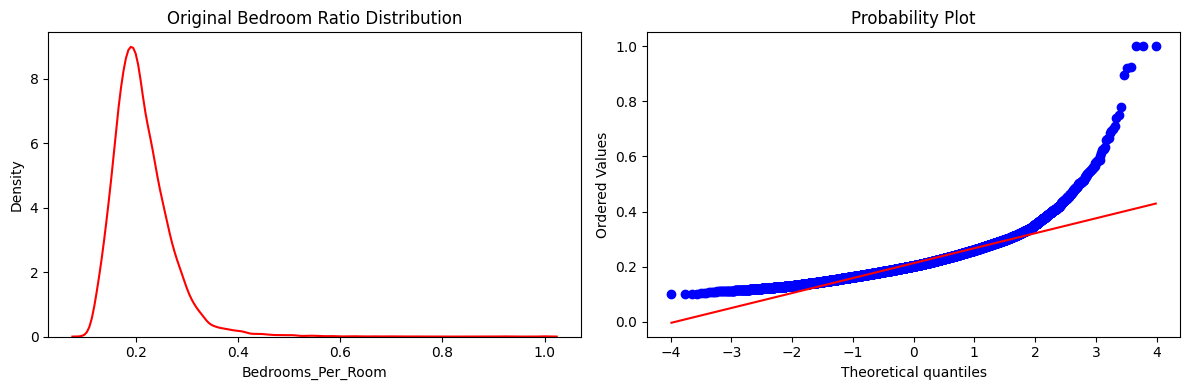

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].set_title('Original Bedroom Ratio Distribution')
sns.kdeplot(df['Bedrooms_Per_Room'], ax=ax[0], color='red')

ax[1].set_title('Original Q-Q Plot')
stats.probplot(df['Bedrooms_Per_Room'], dist='norm', plot=plt)

plt.tight_layout()
plt.show()

**Thinking — Which transformer suits best?Observation: Most homes have a low bedroom-to-room ratio (~0.2), but extremely dense properties create severe right-hand spikes.Skewness: Extreme Right-Skew.Best Choice: Reciprocal Transformer ($\frac{1}{x}$). Inverting fractions shifts tiny ratios into larger numbers and compresses high values.**

In [30]:
# Create reciprocal transformer: 1 / x
reciprocal_transformer = FunctionTransformer(func=lambda x: 1 / x)

# Perform transformation
df['Bedrooms_Per_Room_Reciprocal'] = reciprocal_transformer.fit_transform(df[['Bedrooms_Per_Room']])

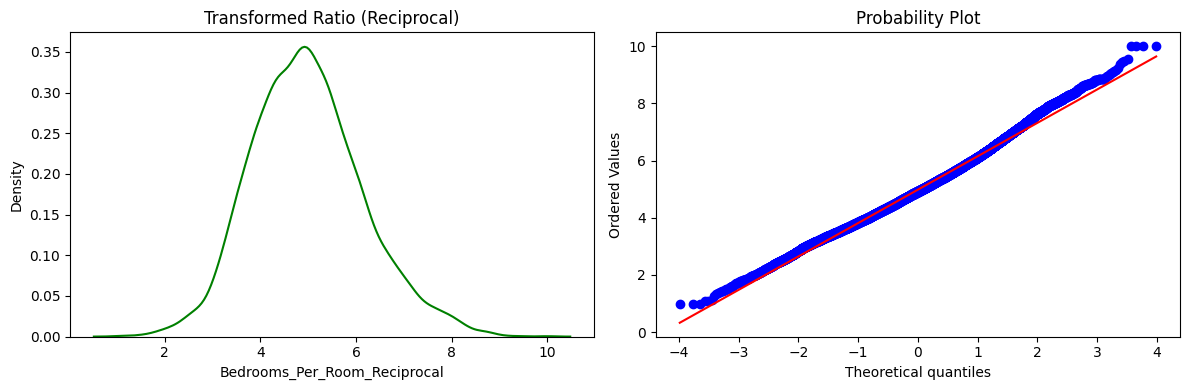

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].set_title('Transformed Ratio (Reciprocal)')
sns.kdeplot(df['Bedrooms_Per_Room_Reciprocal'], ax=ax[0], color='green')

ax[1].set_title('Transformed Q-Q Plot')
stats.probplot(df['Bedrooms_Per_Room_Reciprocal'], dist='norm', plot=plt)

plt.tight_layout()
plt.show()